# 04 — Pourquoi les clients se plaignent

**Objectif** — passer de la nomenclature produit (SARA, COMPTE) à une taxonomie
**causale**, exploitable pour décider quoi corriger et par qui.

| | |
|---|---|
| **Entrée** | périmètre d'analyse défini au notebook 03 (texte enrichi, règle à la journée) |
| **Sorties** | `resultats/tables/04_familles_causales.csv`, `04_operateurs.csv`, `04_audit_non_classes.csv` + 2 figures |
| **Suite** | notebook 05 — récidive et charge |

**Ce que ce notebook établit**

1. Un motif domine tout : *l'argent a quitté le compte et n'est jamais arrivé*.
2. La classification par règles plafonne à ~57 % de rappel, et l'audit manuel
   montre que le reliquat relève très majoritairement **de familles déjà
   identifiées**. Les pourcentages produits ici sont donc des **planchers**.
3. Ce plafond est l'argument chiffré en faveur d'une classification apprise.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from reclamations import chargement, config, texte, viz

viz.appliquer_charte()
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 110)

df = chargement.typer(chargement.charger_brut())
messages = chargement.charger_messages_ouverture()
# perimetre_analyse applique la regle a la journee sur texte enrichi (CSV +
# message d'ouverture recupere dans conversations_.xlsx) et fournit deja
# "texte" / "a_texte" -- notebook 03, §3.4 du protocole.
analyse = chargement.perimetre_analyse(df, messages)
base = analyse[analyse["a_texte"]].copy()

print(f"Base d'analyse : {len(base):,} tickets ({len(base) / len(analyse) * 100:.1f} % du périmètre)")

/home/gauss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Base d'analyse : 8,348 tickets (89.0 % du périmètre)


## 1. Pourquoi le type de ticket ne répond pas à la question

`ticket_type_name` est la catégorie choisie au dépôt. Elle dit dans quel produit
ranger le dossier, pas ce qui a dysfonctionné.

In [2]:
analyse["ticket_type_name"].value_counts().head(6).to_frame("effectif").assign(
    pct=lambda t: (t["effectif"] / len(analyse) * 100).round(1)
)

,effectif,pct
ticket_type_name,,
SARA,5241,55.9
COMPTE,2999,32.0
BENEFICIAIRE ERRONE,541,5.8
CARTE,197,2.1
CREDIT,127,1.4
ACCUEIL,116,1.2


« SARA » et « COMPTE » couvrent 88 % du volume. Savoir qu'une réclamation
concerne SARA ne dit ni ce qui a échoué, ni qui doit corriger. Il faut lire ce
que le client a écrit.

In [3]:
# Les identifiants sont masqués avant affichage : ce notebook est versionné,
# et ses sorties le sont avec lui.
for t in base["texte"].head(5):
    print(" •", texte.masquer_identifiants(t)[:160], "\n")

 • reclamation le 14.07.2026 a 18heures 35 minutes et 03 secondes j'ai effectue un transfert de 15000 de mon compte sara pour mon compte orangemoney. j'ai bien ete 

 • transfert vers orange non abouti 

 • beneficiary error i made a transaction of 10600 on the 26/06/2026 to [TEL] instead of [TEL] 

 • erreur de beneficiaire lors d'une transaction sur l'application sara money j'ai confondu le dernier chiffre de mon numero et le depot est alle ailleurs 

 • cela fait maintenant plusieurs jours que j'ai expose mon probleme sans toutefois avoir la moindre reponse a ma preoccupation. je me retrouve avec un compte au r 



## 2. Taxonomie causale

Six familles, **exclusives**, appliquées dans un ordre de priorité documenté
dans `src/reclamations/texte.py`. Chaque famille porte un **responsable de la
correction** : c'est ce qui rend la taxonomie actionnable. Deux familles de même
volume mais de responsables différents appellent des chantiers différents.

In [4]:
for code, libelle, _motif, responsable in texte.FAMILLES:
    print(f"{code:20s} {libelle:52s} -> {responsable}")

erreur_client        Erreur de saisie du client (mauvais bénéficiaire)    -> UX de l'application
debit_non_credit     Débité sans que le bénéficiaire soit crédité         -> Système (banque <-> opérateur)
acces_otp            Accès bloqué / OTP / authentification                -> Système (authentification)
debit_injustifie     Débit injustifié, doublé, ou frais contestés         -> Système (banque)
carte                Carte bancaire / distributeur                        -> Système (monétique)
demande_info         Demande d'information (pas une réclamation)          -> Hors périmètre réclamation


In [5]:
base["famille"] = texte.classer(base["texte"])
familles = texte.couverture(base["famille"])
chargement.sauver_table(familles, "04_familles_causales")
familles

/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


  -> resultats/tables/04_familles_causales.csv


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


,libelle,responsable,effectif,pct
famille,,,,
non_classe,Non classé par les règles,Indéterminé,3587,43.0
debit_non_credit,Débité sans que le bénéficiaire soit crédité,Système (banque <-> opérateur),3379,40.5
erreur_client,Erreur de saisie du client (mauvais bénéficiaire),UX de l'application,573,6.9
acces_otp,Accès bloqué / OTP / authentification,Système (authentification),319,3.8
debit_injustifie,"Débit injustifié, doublé, ou frais contestés",Système (banque),259,3.1
carte,Carte bancaire / distributeur,Système (monétique),182,2.2
demande_info,Demande d'information (pas une réclamation),Hors périmètre réclamation,49,0.6


## 3. Lecture — et la précaution qui va avec

La famille *débité sans que le bénéficiaire soit crédité* est de loin la
première. Mais **43,0 % des textes ne sont classés par aucune règle**, et cette
ligne est volontairement conservée dans le tableau : la masquer donnerait une
répartition apparemment complète, calculée sur 57 % de la base.

  -> resultats/figures/04_familles_causales.png


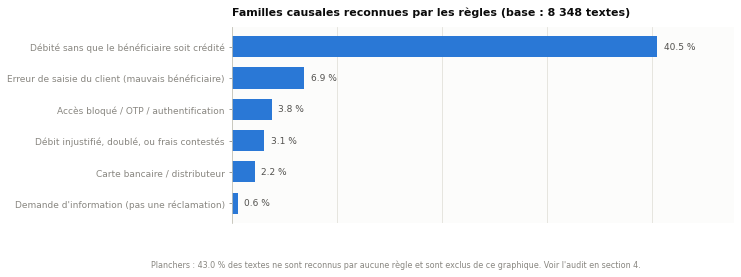

In [6]:
pct_non_classe = (base["famille"] == texte.NON_CLASSE).mean() * 100

fig, ax = plt.subplots(figsize=(9, 3.6))
a_montrer = familles[familles.index != texte.NON_CLASSE]
viz.barres_horizontales(
    a_montrer.set_index("libelle")["pct"],
    f"Familles causales reconnues par les règles (base : {len(base):,} textes)".replace(",", " "),
    unite=" %",
    ax=ax,
    format_valeur="{:.1f}",
)
viz.annoter_source(
    fig,
    f"Planchers : {pct_non_classe:.1f} % des textes ne sont reconnus par aucune règle "
    "et sont exclus de ce graphique. Voir l'audit en section 4.",
)
viz.sauver(fig, "04_familles_causales")
plt.show()

## 4. Audit manuel du reliquat — l'étape qui décide de la suite

Le taux de non-classés ne se commente pas, il s'audite. La question est binaire :
le reliquat est-il **une autre famille** (la taxonomie est incomplète) ou **la
même famille formulée autrement** (les règles sous-estiment une famille connue) ?
Les deux diagnostics mènent à des suites opposées.

L'échantillon est tiré avec une graine fixe : le décompte reporté ci-dessous
reste vérifiable à chaque exécution.

In [7]:
echantillon = texte.echantillon_non_classes(base["texte"], base["famille"], n=20, graine=3)
masque = echantillon.map(texte.masquer_identifiants)

# Le texte de réclamation ne va jamais dans `resultats/tables/`, qui est versionné
# et diffusé. Il part dans `data/audit/`, hors dépôt.
chargement.sauver_audit(masque.rename("texte").to_frame(), "04_audit_non_classes")

for i, t in enumerate(masque, 1):
    print(f"{i:2d}. {t[:110]}")

  -> data/audit/04_audit_non_classes.csv  (hors dépôt, non versionné)
 1. i made a transfer yesterday to an afriland bank account number but i did not get a receipt because of network,
 2. indisponibilite de sara money sara money n'est pas disponible depuis plusieurs jours, qu'est-ce qui se passe ?
 3. bonjour mon sarah money ne fonctionne pas
 4. bonjour j'ai fait une transaction de la banque vers orange money rien jusqu'a present j'ai fait deux operation
 5. reclamation de non versement d'achat
 6. jai fais un retrait ce matin via orange money jusqu'a present rien dans mon compte orange pourtant le compte b
 7. probleme de transfert je fais le transfert vers un numero sans succes
 8. reclamation sara to orange money bonjour j'ai fait une transaction de sara ([TEL]) vers mon compte orange mone
 9. pourquoi je ne peut pas faire un retrait de la banque vers momo. mais un depot est possible de momo vers le co
10. mon compte a ete cree a kribi j'etais mineur. residant actuellement a yaoun

**Décompte manuel sur cet échantillon de 20** (relecture ligne à ligne, sur le
tirage de graine 3 affiché ci-dessus — nouvel échantillon depuis la correction
du bruit HTML dans le texte enrichi, notebook 03 : le périmètre a changé une
nouvelle fois, donc l'échantillon tiré avec la même graine porte encore sur
des textes différents des deux versions précédentes de ce notebook) :

| Famille réelle | Lignes | Nombre |
|---|---|---|
| Débité sans que le bénéficiaire soit crédité | 1, 4, 5, 6, 7, 8, 11, 12, 15, 17, 18, 19 | 12 |
| Autre (dysfonctionnement applicatif ou hors taxonomie) | 2, 3, 9, 10 | 4 |
| Débit injustifié / doublé | 16, 20 | 2 |
| Accès bloqué / OTP / authentification | 13 | 1 |
| Demande d'information | 14 | 1 |

Aucun texte de cet échantillon ne relève de *erreur de saisie du client* ni de
*carte* — absentes de ce tirage précis, pas nulles dans l'absolu : les audits
précédents (versions antérieures de ce notebook) en avaient rencontré
plusieurs. Avec 20 textes par tirage, ce genre de variation est attendu, pas
un signal que ces familles ont disparu.

> **Conclusion de l'audit — inchangée dans sa nature.**
>
> 1. La taxonomie reste **trouée mais pas fausse** : 16 des 20 textes
>    relèvent d'une famille déjà définie. Les 4 « autre » confirment à nouveau
>    l'existence d'un dysfonctionnement applicatif ou administratif hors flux
>    d'argent, non couvert par les 6 familles actuelles (§4.2 du protocole —
>    écart A2, toujours ouvert) : indisponibilité du service (« sara money
>    n'est pas disponible depuis plusieurs jours »), restriction fonctionnelle
>    (retrait impossible dans un sens), demande administrative (mise à jour
>    d'un compte ouvert mineur).
> 2. La famille dominante (*débité sans que le bénéficiaire soit crédité*)
>    pèse plus lourd dans ce tirage (12/20) que dans les précédents — variation
>    d'échantillonnage, à ne pas lire comme une hausse réelle du phénomène.

### Estimation corrigée

En reportant la structure de l'audit sur l'ensemble du reliquat.

In [8]:
# Décompte de l'audit manuel ci-dessus (20 textes, graine 3), centralisé dans
# `config.AUDIT_MANUEL` / `config.AUDIT_MANUEL_HORS_TAXONOMIE` -- réutilisé tel
# quel par le notebook 06, pour qu'un seul endroit porte cette correction
# (règle d'intégralité, protocole §5.1 : toutes les familles observées dans
# l'audit sont redistribuées, aucune n'est écartée).
assert sum(config.AUDIT_MANUEL.values()) + sum(config.AUDIT_MANUEL_HORS_TAXONOMIE.values()) == config.AUDIT_MANUEL_TAILLE

corrige = texte.estimation_corrigee(familles)
part_non_classe = familles.loc[texte.NON_CLASSE, "pct"]
print(f"Non classés par les règles : {part_non_classe:.1f} % de la base\n")
for famille, ligne in corrige.iterrows():
    print(
        f"{famille:48s} règles {ligne['pct_regles']:5.1f} %  "
        f"+ reliquat {ligne['pct_reliquat']:4.1f} pts  ->  ~{ligne['pct_corrige']:.0f} %"
    )

# Le cumul narratif « argent prélevé à tort ou jamais arrivé » (section suivante)
# ne porte que sur les deux familles qui décrivent un préjudice financier direct
# imputable à la banque — pas l'erreur de saisie du client, ni la carte/GAB, ni
# le dysfonctionnement applicatif, qui sont des histoires différentes.
familles_prejudice = [texte.libelles()["debit_non_credit"], texte.libelles()["debit_injustifie"]]
total = corrige.loc[familles_prejudice, "pct_corrige"].sum()
print(f"\n{'Cumul « l argent a été pris à tort »':48s} {'':22s}  ->  ~{total:.0f} %")

Non classés par les règles : 43.0 % de la base

Débité sans que le bénéficiaire soit crédité     règles  40.5 %  + reliquat 25.8 pts  ->  ~66 %
Débit injustifié, doublé, ou frais contestés     règles   3.1 %  + reliquat  4.3 pts  ->  ~7 %
Accès bloqué / OTP / authentification            règles   3.8 %  + reliquat  2.2 pts  ->  ~6 %
Demande d'information (pas une réclamation)      règles   0.6 %  + reliquat  2.2 pts  ->  ~3 %
dysfonctionnement_application / hors taxonomie (§4.2) règles   0.0 %  + reliquat  8.6 pts  ->  ~9 %

Cumul « l argent a été pris à tort »                                     ->  ~74 %


> **Environ deux tiers des réclamations** disent : *mon compte a été débité, le
> bénéficiaire n'a rien reçu.* En y ajoutant les débits injustifiés ou doublés,
> **environ 74 %, soit un peu moins de trois quarts**, portent sur de l'argent
> prélevé à tort ou jamais arrivé.

**Précaution.** Cette correction repose sur un audit de 20 textes : l'intervalle
de confiance à 95 % sur une proportion proche de 12/20 est d'environ ±20 points. C'est
un **ordre de grandeur**, pas une mesure.

C'est exactement pour cela que l'étape suivante du projet est une classification
apprise — pour remplacer cette extrapolation par une mesure, sur les 8 348
textes de la base.

## 5. Qui doit corriger ?

Regroupement des familles par responsable de la correction.

In [9]:
base["responsable"] = base["famille"].map(texte.responsables())
par_responsable = (
    base[base["famille"] != texte.NON_CLASSE]["responsable"]
    .value_counts()
    .to_frame("effectif")
)
par_responsable["pct_des_classes"] = (
    par_responsable["effectif"] / par_responsable["effectif"].sum() * 100
).round(1)
chargement.sauver_table(par_responsable, "04_par_responsable")
par_responsable

  -> resultats/tables/04_par_responsable.csv


,effectif,pct_des_classes
responsable,,
Système (banque <-> opérateur),3379,71.0
UX de l'application,573,12.0
Système (authentification),319,6.7
Système (banque),259,5.4
Système (monétique),182,3.8
Hors périmètre réclamation,49,1.0


**Point d'action isolé par cette lecture.** L'erreur de saisie du bénéficiaire
est la seule famille dont la correction ne dépend pas d'un diagnostic technique :
afficher le nom du titulaire avant validation du transfert — ce que font déjà
les opérateurs de mobile money — supprime le motif à la source. C'est le seul
gisement que ces données permettent à la fois de chiffrer et de corriger sans
donnée supplémentaire.

## 6. Opérateur mis en cause et sens du flux

Sur les tickets de la famille dominante uniquement.

In [10]:
dominante = base[base["famille"] == "debit_non_credit"]["texte"]

operateurs = texte.detecter(dominante, texte.OPERATEURS)
chargement.sauver_table(operateurs, "04_operateurs")
operateurs

/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:406: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  m = texte.str.contains(motif, regex=True, na=False)


  -> resultats/tables/04_operateurs.csv


,mentions,pct,base
motif,,,
Orange Money,1603,47.4,3379
MTN MoMo,307,9.1,3379
Autre banque,15,0.4,3379


In [11]:
flux = texte.detecter(dominante, texte.SENS_FLUX)
chargement.sauver_table(flux, "04_sens_flux")
flux

  -> resultats/tables/04_sens_flux.csv


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:406: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  m = texte.str.contains(motif, regex=True, na=False)


,mentions,pct,base
motif,,,
Sortant (SARA -> mobile money),1136,33.6,3379
Entrant (banque/MoMo -> SARA),164,4.9,3379


**Deux pistes, à ne pas confondre avec des conclusions.**

- Le sens **sortant** (SARA → mobile money) est cité bien plus souvent que
  l'entrant. La casse semble concentrée sur une direction du flux.
- Orange Money est cité plusieurs fois plus que MTN. **Cet écart n'est pas
  interprétable en l'état** : il est confondu avec les parts de marché
  respectives des deux opérateurs dans la base client. Un décompte de mentions
  n'est pas un taux de défaillance.

> Pour transformer ces deux pistes en diagnostic, il faut le **dénominateur** :
> le volume de transactions par opérateur et par sens de flux. Il est absent de
> cet export — voir la conclusion du notebook 06.

## 7. Exposition financière — ordre de grandeur

Les montants ne sont fiables ni en agrégat ni en moyenne (valeurs négatives,
nulles, et un amas artificiel entre 690 M et 700 M XAF). On ne retient que des
montants plausibles, et on lit la **médiane**, insensible aux valeurs extrêmes.

In [12]:
mt = chargement.montants_plausibles(base)
expo = mt.groupby("famille")["montant"].agg(
    tickets="count", mediane="median", total="sum"
).sort_values("tickets", ascending=False)
chargement.sauver_table(expo.round(0), "04_exposition_par_famille")
expo.round(0)

  -> resultats/tables/04_exposition_par_famille.csv


,tickets,mediane,total
famille,,,
debit_non_credit,3172,50000.0,430790278.0
non_classe,2586,50000.0,478810333.0
erreur_client,274,49750.0,25824050.0
debit_injustifie,229,40000.0,30640533.0
carte,124,100000.0,24135272.0
acces_otp,85,50000.0,17583696.0
demande_info,22,37500.0,6190747.0


> **Aucun de ces totaux ne doit être communiqué comme un chiffre officiel.** Ils
> ne portent que sur les tickets dont le montant est renseigné et plausible, et
> le champ n'a pas été validé par le métier. Ils servent à hiérarchiser les
> familles entre elles, pas à chiffrer un préjudice.